In [12]:
import pandas as pd
import numpy as np

## Load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [13]:
dataset=pd.read_csv('/content/drive/My Drive/Colab Notebooks/Datasets/diabetes.csv')

In [14]:
dataset.shape

(768, 9)

In [15]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## spliting dataset


In [17]:
x=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1:].values



## spliting train and test

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)


feature scaling

In [19]:
from  sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


## finding best depth

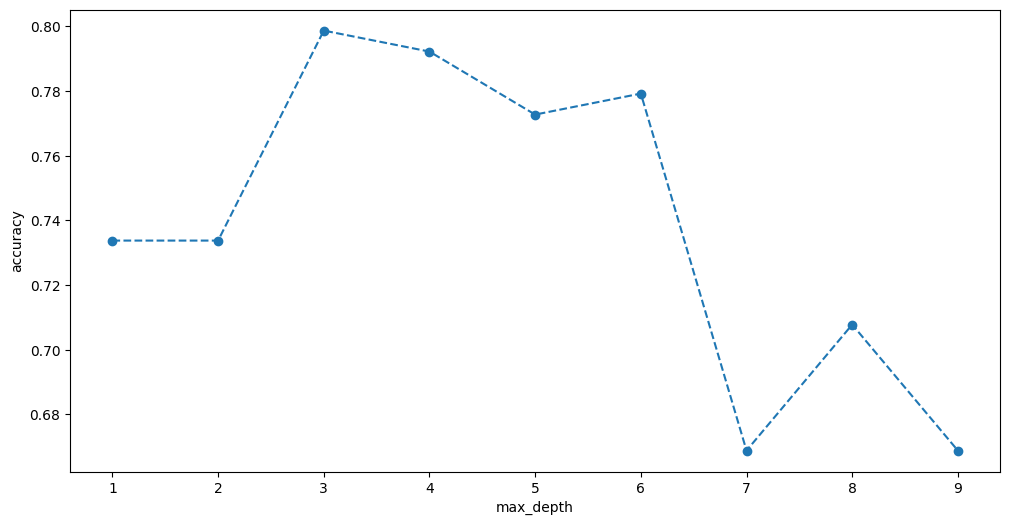

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
accuracy=[]
for i in range(1,10):
  model=DecisionTreeClassifier(criterion='entropy',max_depth=i,random_state=1)
  model.fit(x_train,y_train)
  pred=model.predict(x_test)
  accuracy.append(accuracy_score(y_test,pred))

plt.figure(figsize=(12,6))
plt.plot(range(1,10),accuracy,marker='o',linestyle='--')
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.show()



In [21]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.7922077922077922
